In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import astropy.constants as c

import sys
from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

import Plots
importlib.reload(Plots)

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

Dust profiles are necessary for some tSZ measurements to account for contamination.

In [5]:
import Models.Dust as Dust
import Models.Studies as Studies
importlib.reload(Dust)
importlib.reload(Studies)

AmodeoDust = Dust.Amodeo2021({'fitdata':'ACTHr'})

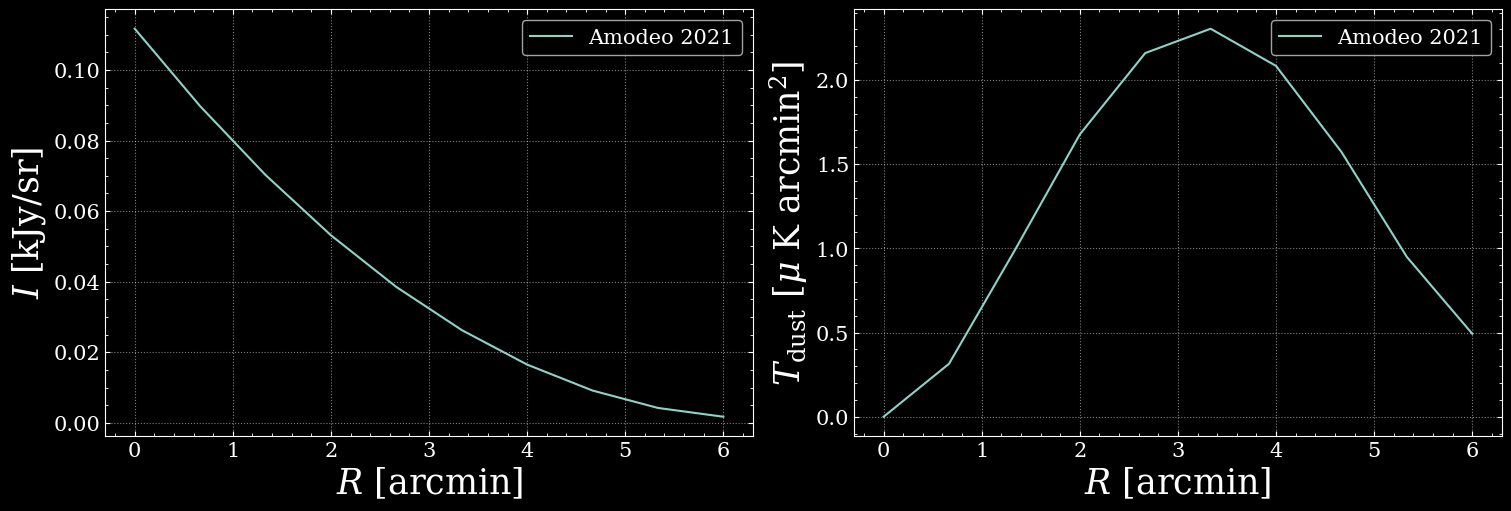

In [7]:
Rs = np.linspace(0, 6, 10)
freq = 150*u.GHz

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

axs[0].plot(Rs, AmodeoDust.dustpoly(Rs, freq)(), label='Amodeo 2021')
axs[1].plot(Rs, AmodeoDust.dust_uKarcmin(Rs, freq)(), label='Amodeo 2021')

axs[0].set(xlabel=r'$R$ [arcmin]', ylabel=r'$I$ [kJy/sr]'); axs[0].legend()
axs[1].set(xlabel=r'$R$ [arcmin]', ylabel=r'$T_\text{dust}$ [$\mu$ K arcmin$^2$]'); axs[1].legend()

plt.show()

# Amodeo 2021

In [ ]:
import Studies, Dust
importlib.reload(Studies); importlib.reload(Dust)

AmodeoDustHr = Dust.Amodeo2021({'fitdata':'Hr'})
AmodeoDustAHr = Dust.Amodeo2021({'fitdata':'ACTHr'})
nu = lambda L: (c.c/(L*u.um)).to(u.GHz)

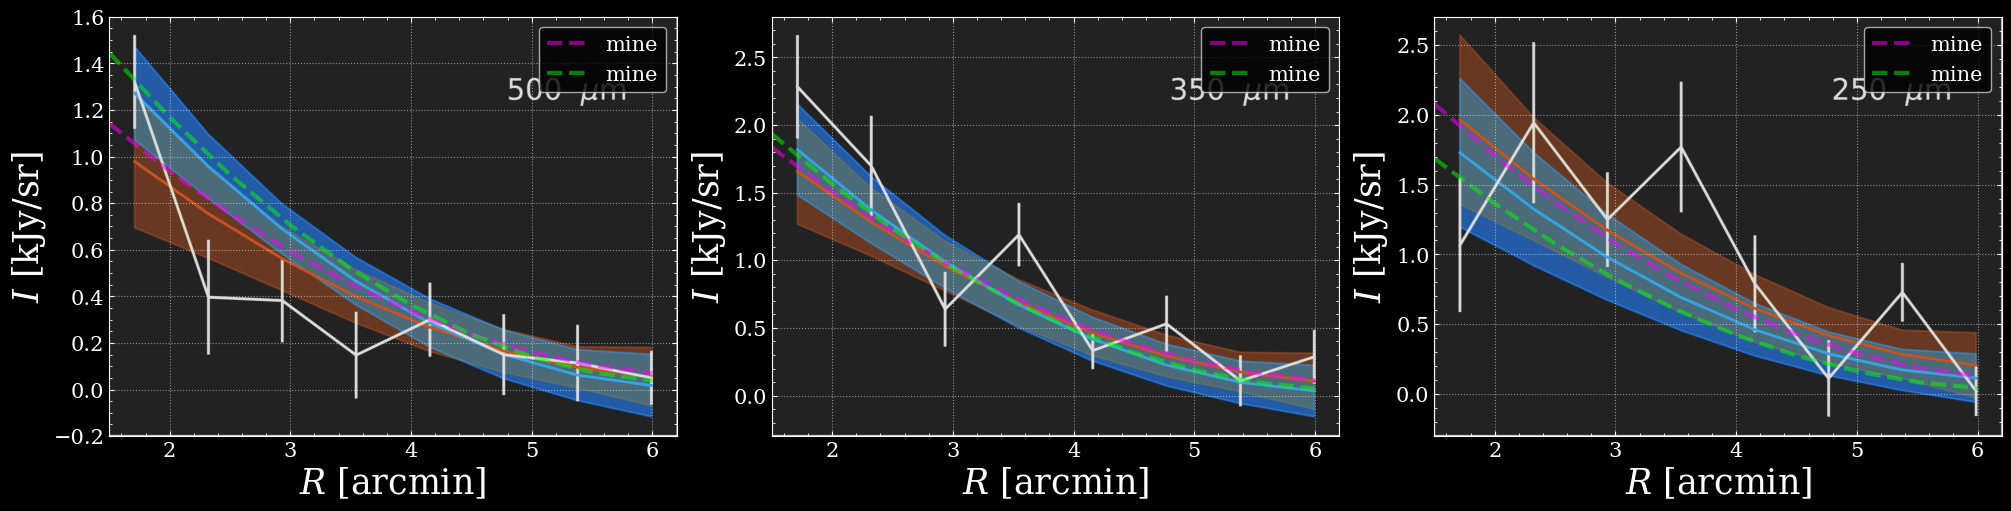

In [8]:
fig, axs = Plots.Amodeo2021().Fig11_row2()

Rs = np.linspace(1.5, 6, 10)

axs[0].plot(Rs, AmodeoDustHr.dustpoly(Rs, nu(500))(), lw=3, c='magenta', alpha=0.5, ls='--', label='mine')
axs[0].plot(Rs, AmodeoDustAHr.dustpoly(Rs, nu(500))(), lw=3, c='lime', alpha=0.5, ls='--', label='mine')

axs[1].plot(Rs, AmodeoDustHr.dustpoly(Rs, nu(350))(), lw=3, c='magenta', alpha=0.5, ls='--', label='mine')
axs[1].plot(Rs, AmodeoDustAHr.dustpoly(Rs, nu(350))(), lw=3, c='lime', alpha=0.5, ls='--',label='mine')

axs[2].plot(Rs, AmodeoDustHr.dustpoly(Rs, nu(250))(), lw=3, c='magenta', alpha=0.5, ls='--', label='mine')
axs[2].plot(Rs, AmodeoDustAHr.dustpoly(Rs, nu(250))(), lw=3, c='lime', alpha=0.5, ls='--', label='mine')

axs[0].legend(); axs[1].legend(); axs[2].legend()

plt.show()

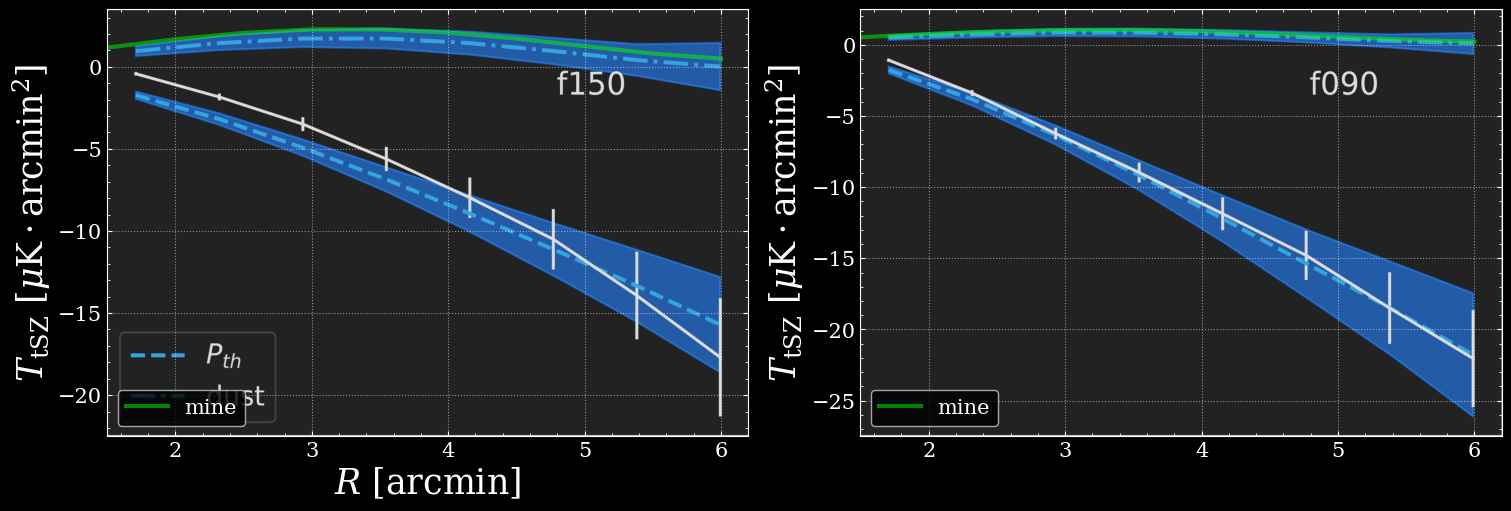

In [11]:
import Models.Plots as Plots
importlib.reload(Plots)

fig, axs = Plots.Amodeo2021().Fig11_row3()

Rs = np.linspace(1.5, 6, 10)

axs[0].plot(Rs, AmodeoDustAHr.dust_uKarcmin(Rs, 150*u.GHz)(), lw=3, c='lime', alpha=0.5, label='mine')

axs[1].plot(Rs, AmodeoDustAHr.dust_uKarcmin(Rs, 90*u.GHz)(), lw=3, c='lime', alpha=0.5,label='mine')

axs[0].legend(); axs[1].legend()
plt.show()